# Исследование рынка видеоигр 2000–2013 гг.



### Цели и задачи проекта

Цель проекта — выявить особенности рынка видеоигр в актуальный период (2000–2013 годы): определить распределение игр по оценкам критиков и пользователей, а также выделить платформы, которые были наиболее популярны по количеству выпущенных игр.Выявить особенности рынка видеоигр за актуальный период (2000–2013 годы): понять, как распределяются игры по оценкам критиков и пользователей, а также какие платформы были наиболее популярны по количеству выпущенных игр.

Задачи проекта
1. Подготовка данных
2. Создание новых признаков
3. Анализ оценок
4. Анализ платформ

### Описание данных

   В работе используется датасет с информацией о видеоиграх, содержащий сведения о названиях, платформах, годах релиза, жанрах, региональных и глобальных продажах, а также оценках критиков и пользователей.


### Содержимое проекта

1. Загрузка данных и знакомство с ними  

2. Проверка ошибок в данных и их предобработка  
   2.1. Названия, или метки, столбцов датафрейма  
   2.2. Типы данных  
   2.3. Наличие пропусков в данных  
   2.4. Явные и неявные дубликаты в данных  

3. Фильтрация данных  

4. Категоризация данных  

5. Итоговый вывод


## 1. Загрузка данных и знакомство с ними

- Загрузите необходимые библиотеки Python и данные датасета `/datasets/new_games.csv`.


In [1]:
# загружаем библиотеку pandas
import pandas as pd

In [2]:
# загружаем датасет
df=pd.read_csv('/datasets/new_games.csv')

- Познакомьтесь с данными: выведите первые строки и результат метода `info()`.


In [3]:
# выводим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16954 non-null  object 
 1   Platform         16956 non-null  object 
 2   Year of Release  16681 non-null  float64
 3   Genre            16954 non-null  object 
 4   NA sales         16956 non-null  float64
 5   EU sales         16956 non-null  object 
 6   JP sales         16956 non-null  object 
 7   Other sales      16956 non-null  float64
 8   Critic Score     8242 non-null   float64
 9   User Score       10152 non-null  object 
 10  Rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB


In [4]:
# выводим первые 10 строк
df.head(10)

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.5,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.7,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Датасет содержит 16 956 строк и 11 столбцов с информацией об играх. 

В данных есть пропуски по году выпуска, названиям, жанрам, оценкам и рейтингам, причём особенно много пропусков в Critic Score, User Score и Rating.

EU sales, JP sales, User Scor имеют тип object, что говорит о наличии строковых значений и потребует дополнительной очистки и преобразования типов.

Названия столбцов содержат пробелы и не соответствуют стилю snake_case, поэтому для удобства анализа их нужно привести к единому формату (нижний регистр, подчёркивания вместо пробелов).

---

## 2.  Проверка ошибок в данных и их предобработка


### 2.1. Названия, или метки, столбцов датафрейма

- Выведите на экран названия всех столбцов датафрейма и проверьте их стиль написания.
- Приведите все столбцы к стилю snake case. Названия должны быть в нижнем регистре, а вместо пробелов — подчёркивания.

In [5]:
# выводим названия столбцов
df.columns

Index(['Name', 'Platform', 'Year of Release', 'Genre', 'NA sales', 'EU sales',
       'JP sales', 'Other sales', 'Critic Score', 'User Score', 'Rating'],
      dtype='object')

In [6]:
# приводим названия к стилю snake case
df.columns = df.columns.str.lower().str.replace(' ', '_')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Молодец! Приводим названия колонок к общепринятому стилю и не используем длинный словарь для переименования названий! 😉 </font>

In [7]:
# проверяем обновенные названия
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16954 non-null  object 
 1   platform         16956 non-null  object 
 2   year_of_release  16681 non-null  float64
 3   genre            16954 non-null  object 
 4   na_sales         16956 non-null  float64
 5   eu_sales         16956 non-null  object 
 6   jp_sales         16956 non-null  object 
 7   other_sales      16956 non-null  float64
 8   critic_score     8242 non-null   float64
 9   user_score       10152 non-null  object 
 10  rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB


### 2.2. Типы данных



Столбец year_of_release имеет тип float64, хотя год — целое число. Столбцы eu_sales, jp_sales, user_score имеют тип object, хотя по описанию должны быть числа


Возможно столбце с годом есть пропуски, поэтому при чтении он стал float64. Могут быть лишние пробелы, запятые вместо точек или другие символы, которые мешают распознать число, поэтому столбец тоже попадает в object.


In [10]:
# выводим уникальные значения по столбцу year_of_release
df['year_of_release'].unique()

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

Столбец year_of_release содержит годы в числовом формате, но присутствуют пропуски (NaN), из-за которых столбец имеет тип object вместо числового.

In [11]:
# выводим уникальные значения по столбцу jp_sales
df['jp_sales'].unique()

array(['3.77', '6.81', '3.79', '3.28', '10.22', '4.22', '6.5', '2.93',
       '4.7', '0.28', '1.93', '4.13', '7.2', '3.6', '0.24', '2.53',
       '0.98', '0.41', '3.54', '4.16', '6.04', '4.18', '3.84', '0.06',
       '0.47', '5.38', '5.32', '5.65', '1.87', '0.13', '3.12', '0.36',
       '0.11', '4.35', '0.65', '0.07', '0.08', '0.49', '0.3', '2.66',
       '2.69', '0.48', '0.38', '5.33', '1.91', '3.96', '3.1', '1.1',
       '1.2', '0.14', '2.54', '2.14', '0.81', '2.12', '0.44', '3.15',
       '1.25', '0.04', '0.0', '2.47', '2.23', '1.69', '0.01', '3.0',
       '0.02', '4.39', '1.98', '0.1', '3.81', '0.05', '2.49', '1.58',
       '3.14', '2.73', '0.66', '0.22', '3.63', '1.45', '1.31', '2.43',
       '0.7', '0.35', '1.4', '0.6', '2.26', '1.42', '1.28', '1.39',
       '0.87', '0.17', '0.94', '0.19', '0.21', '1.6', '0.16', '1.03',
       '0.25', '2.06', '1.49', '1.29', '0.09', '2.87', '0.03', '0.78',
       '0.83', '2.33', '2.02', '1.36', '1.81', '1.97', '0.91', '0.99',
       '0.95', '2.0'

В столбце jp_sales числовые значения в формате строк, но присутствует 'unknown', из-за чего тип столбца остался object.

In [12]:
# выводим уникальные значения по столбцу user_score
df['user_score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

В столбце user_score — оценки представлены как строки, но наличие 'tbd' и пропусков не позволяет автоматически преобразовать столбец в числовой тип.



In [13]:
# выводим уникальрые значения по столбцу eu_sales
df['eu_sales'].unique()

array(['28.96', '3.58', '12.76', '10.93', '8.89', '2.26', '9.14', '9.18',
       '6.94', '0.63', '10.95', '7.47', '6.18', '8.03', '4.89', '8.49',
       '9.09', '0.4', '3.75', '9.2', '4.46', '2.71', '3.44', '5.14',
       '5.49', '3.9', '5.35', '3.17', '5.09', '4.24', '5.04', '5.86',
       '3.68', '4.19', '5.73', '3.59', '4.51', '2.55', '4.02', '4.37',
       '6.31', '3.45', '2.81', '2.85', '3.49', '0.01', '3.35', '2.04',
       '3.07', '3.87', '3.0', '4.82', '3.64', '2.15', '3.69', '2.65',
       '2.56', '3.11', '3.14', '1.94', '1.95', '2.47', '2.28', '3.42',
       '3.63', '2.36', '1.71', '1.85', '2.79', '1.24', '6.12', '1.53',
       '3.47', '2.24', '5.01', '2.01', '1.72', '2.07', '6.42', '3.86',
       '0.45', '3.48', '1.89', '5.75', '2.17', '1.37', '2.35', '1.18',
       '2.11', '1.88', '2.83', '2.99', '2.89', '3.27', '2.22', '2.14',
       '1.45', '1.75', '1.04', '1.77', '3.02', '2.75', '2.16', '1.9',
       '2.59', '2.2', '4.3', '0.93', '2.53', '2.52', '1.79', '1.3', '2.6',
   

В столбце eu_sales числовые значения в формате строк, но присутствует 'unknown', из-за чего тип столбца остался object

In [14]:
# список столбцов, которые должны быть числовыми, но сейчас имеют тип object
cols_to_convert = ['eu_sales', 'jp_sales', 'user_score']

In [15]:
# для каждого столбца в списке пытаемся привести значения к числовому типу,
# все строковые значения заменяем на пропуски
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [16]:
# выводим обновленную информацию 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16954 non-null  object 
 1   platform         16956 non-null  object 
 2   year_of_release  16681 non-null  float64
 3   genre            16954 non-null  object 
 4   na_sales         16956 non-null  float64
 5   eu_sales         16950 non-null  float64
 6   jp_sales         16952 non-null  float64
 7   other_sales      16956 non-null  float64
 8   critic_score     8242 non-null   float64
 9   user_score       7688 non-null   float64
 10  rating           10085 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.4+ MB


### 2.3. Наличие пропусков в данных



In [17]:
# количество пропусков в каждом столбце
df.isna().sum()

name                  2
platform              0
year_of_release     275
genre                 2
na_sales              0
eu_sales              6
jp_sales              4
other_sales           0
critic_score       8714
user_score         9268
rating             6871
dtype: int64

In [18]:
# доля пропусков в каждом столбце
df.isna().sum() / len(df) * 100

name                0.011795
platform            0.000000
year_of_release     1.621845
genre               0.011795
na_sales            0.000000
eu_sales            0.035386
jp_sales            0.023590
other_sales         0.000000
critic_score       51.391838
user_score         54.659118
rating             40.522529
dtype: float64

В данных присутствуют пропуски почти во всех столбцах, за исключением platform, na_sales и other_sales. Наибольшее количество пропусков приходится на оценки и рейтинг: 8714 значений в critic_score (≈51%), 9268 в user_score (≈55%) и 6871 в rating (≈41%). В столбце year_of_release отсутствует 275 значений (≈1.6%), а в name и genre — всего по 2 пропуска; продажи в Европе и Японии содержат единичные пропуски (6 и 4 соответственно).

Вероятные причины пропусков — отсутствие информации об оценках и рейтинге для части игр, неполные данные по годам выпуска и продажам в отдельных регионах, а также технические ошибки при сборе данных. В дальнейшей работе строки с пропусками в name, genre, year_of_release, а также единичные пропуски в eu_sales и jp_sales можно удалить: их доля невелика и они могут мешать анализу по годам и регионам. Пропуски в critic_score, user_score и rating целесообразно сохранить как есть и учитывать при анализе, так как доля отсутствующих значений слишком велика.

In [20]:
# удаляем строки с пропусками в name и genre
df = df.dropna(subset = ['name', 'genre'])

In [21]:
# удаляем строки без года выпуска
df = df.dropna(subset = ['year_of_release'])

In [22]:
# считаем средние продажи по платформе+году для eu_sales
mean_eu_sales = df.groupby(['platform', 'year_of_release'])['eu_sales'].mean()

# функция для заполнения пропусков в eu_sales
def fill_eu_sales(row):
    if pd.isna(row['eu_sales']):  # если значение пропущено
        avg = mean_eu_sales.get((row['platform'], row['year_of_release']), 0)
        return avg
    return row['eu_sales']  # возвращаем оригинал, если не пропуск

# применяем функцию к каждой строке
df['eu_sales'] = df.apply(fill_eu_sales, axis=1)

# функция для заполнения пропусков в jp_sales
mean_jp_sales = df.groupby(['platform', 'year_of_release'])['jp_sales'].mean()

def fill_jp_sales(row):
    if pd.isna(row['jp_sales']):
        avg = mean_jp_sales.get((row['platform'], row['year_of_release']), 0)
        return avg
    return row['jp_sales']

df['jp_sales'] = df.apply(fill_jp_sales, axis=1)

# проверка сколько пропусков осталось
print("Пропуски в eu_sales:", df['eu_sales'].isna().sum())
print("Пропуски в jp_sales:", df['jp_sales'].isna().sum())
    

Пропуски в eu_sales: 0
Пропуски в jp_sales: 0


In [23]:
# проверяем, что осталось после удаления пропусков
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16679 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16679 non-null  object 
 1   platform         16679 non-null  object 
 2   year_of_release  16679 non-null  float64
 3   genre            16679 non-null  object 
 4   na_sales         16679 non-null  float64
 5   eu_sales         16679 non-null  float64
 6   jp_sales         16679 non-null  float64
 7   other_sales      16679 non-null  float64
 8   critic_score     8085 non-null   float64
 9   user_score       7558 non-null   float64
 10  rating           9901 non-null   object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


In [24]:
# приводим столбец год выпуска к целочисленному типу
df['year_of_release'] = df['year_of_release'].astype('int64')

In [25]:
# проверяем результат
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16679 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16679 non-null  object 
 1   platform         16679 non-null  object 
 2   year_of_release  16679 non-null  int64  
 3   genre            16679 non-null  object 
 4   na_sales         16679 non-null  float64
 5   eu_sales         16679 non-null  float64
 6   jp_sales         16679 non-null  float64
 7   other_sales      16679 non-null  float64
 8   critic_score     8085 non-null   float64
 9   user_score       7558 non-null   float64
 10  rating           9901 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


Пропуски в critic_score, user_score и rating сознательно оставлены.Эти столбцы содержат очень большую долю отсутствующих значений, что, скорее всего, связано с тем, что часть игр не получала оценок критиков и пользователей или официального ESRB‑рейтинга. Если удалять все строки с пропусками в этих полях или заполнять их вымышленными значениями (например, средними), это сильно исказит картину и значительно уменьшит выборку.

### 2.4. Явные и неявные дубликаты в данных



In [27]:
# жанры
df['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy', 'MISC', 'ROLE-PLAYING', 'RACING', 'ACTION', 'SHOOTER',
       'FIGHTING', 'SPORTS', 'PLATFORM', 'ADVENTURE', 'SIMULATION',
       'PUZZLE', 'STRATEGY'], dtype=object)

In [28]:
# приводим жанры к единому стилю
df['genre'] = df['genre'].str.lower()

In [29]:
# смотрим, что получилось
sorted(df['genre'].unique())

['action',
 'adventure',
 'fighting',
 'misc',
 'platform',
 'puzzle',
 'racing',
 'role-playing',
 'shooter',
 'simulation',
 'sports',
 'strategy']

In [30]:
# платформы
df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [31]:
# рейтинг 
df['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [32]:
# годы выпуска
df['year_of_release'].unique()

array([2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010,
       2013, 2004, 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014,
       1992, 1997, 1993, 1994, 1982, 2016, 2003, 1986, 2000, 1995, 1991,
       1981, 1987, 1980, 1983])

In [33]:
# проверяем, сколько полностью одинаковых строк в датафрейме
df.duplicated().sum()


235

In [34]:
# удаляем полностью дублирующиеся строки, сохраняем только первые вхождения
df = df.drop_duplicates().reset_index(drop=True)


In [35]:
# проверяем
df.duplicated().sum()

0

В данных после нормализации категориальных признаков было обнаружено 235 явных дубликатов строк. Все полностью совпадающие записи были удалены с помощью метода drop_duplicates(), после чего индексы датафрейма были пересозданы командой reset_index(drop=True) для сохранения непрерывной нумерации строк. 

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16444 entries, 0 to 16443
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [37]:
# начальные строки
initial_rows = 16956
# финальные с троки
final_rows = 16444

In [38]:
# считаем количество строк
removed_rows = initial_rows - final_rows  
removed_rows

512

In [39]:
# считаем долю 
removed_pct = removed_rows / initial_rows * 100
removed_pct

3.019580089643784

In [40]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(tmp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 16956 
 Осталось строк в датасете после обработки 16444 
 Удалено строк в датасете после обработки 512 
 Процент потерь 3.02


В процессе предобработки данных объём датасета уменьшился с 16956 до 16444 строк, то есть было удалено 512 строк, что составляет примерно 3% от исходного числа наблюдений. Удалялись строки с пропусками в ключевых столбцах (name, genre — по 2 значения, year_of_release — 275 значений), пропуски в eu_sales  и jp_sales заполнены средним значением по платформе и году выпуска, оценки (critic_score, user_score, rating) сохранены из-за высокой доли пропусков. Жанры приведены к нижнему регистру для устранения неявных дубликатов, year_of_release переведён в int64, удалены явные дубликаты.

---

## 3. Фильтрация данных



In [41]:
# создаём срез данных за период 2000–2013 годов включительно
df_actual = df[(df['year_of_release'] >= 2000) & (df['year_of_release'] <= 2013)].copy()

In [42]:
# проверяем новый датафрейм
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12781 entries, 0 to 16442
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             12781 non-null  object 
 1   platform         12781 non-null  object 
 2   year_of_release  12781 non-null  int64  
 3   genre            12781 non-null  object 
 4   na_sales         12781 non-null  float64
 5   eu_sales         12781 non-null  float64
 6   jp_sales         12781 non-null  float64
 7   other_sales      12781 non-null  float64
 8   critic_score     7169 non-null   float64
 9   user_score       6483 non-null   float64
 10  rating           8723 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.2+ MB


In [43]:
# Комментарий ревьюера
df_actual.year_of_release.sort_values().unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013])

---

## 4. Категоризация данных
    


In [44]:
# функция для категорий по пользователям
def user_score_category(score):
    if pd.isna(score):
        return 'Нет результатов'
    elif 8 <= score <= 10:
        return 'Высокая оценка'
    elif 3 <= score < 8:
        return 'Средняя оценка'
    elif 0 <= score < 3:
        return 'Низкая оценка'
    else:
        return 'Нет результатов'
    
df_actual['user_score_category'] = df_actual['user_score'].apply(user_score_category)

In [45]:
# функция для категорий по критикам
def critic_score_category(score):
    if pd.isna(score):
        return 'Нет результатов'
    elif 80 <= score <= 100:
        return 'Высокая оценка'
    elif 30 <= score < 80:
        return 'Средняя оценка'
    elif 0 <= score < 30:
        return 'Низкая оценка'
    else:
        return 'Нет результатов'
    
df_actual['critic_score_category'] = df_actual['critic_score'].apply(critic_score_category)

- После категоризации данных проверьте результат: сгруппируйте данные по выделенным категориям и посчитайте количество игр в каждой категории.

In [46]:
# группировка данных по критикам
df_actual.groupby(['critic_score_category'])['name'].count()

critic_score_category
Высокая оценка     1692
Нет результатов    5612
Низкая оценка        55
Средняя оценка     5422
Name: name, dtype: int64

In [47]:
# группировка данных по пользователям
df_actual.groupby(['user_score_category'])['name'].count()

user_score_category
Высокая оценка     2286
Нет результатов    6298
Низкая оценка       116
Средняя оценка     4081
Name: name, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, сделали проверку данных отзывов по категориям.</font>

- Выделите топ-7 платформ по количеству игр, выпущенных за весь актуальный период.

In [48]:
# Выделяем топ-7
top7_platforms = (
    df_actual
        .groupby('platform')['name']   # группируем по платформе
        .count()                      # считаем игры на каждой
        .sort_values(ascending=False) # сортируем по убыванию
        .head(7)                      # берём топ-7
)
top7_platforms


platform
PS2     2127
DS      2120
Wii     1275
PSP     1180
X360    1121
PS3     1087
GBA      811
Name: name, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно выведен ТОП-7 платформ по количеству выпущенных игр.</font>

In [49]:
df_actual.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12781 entries, 0 to 16442
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   12781 non-null  object 
 1   platform               12781 non-null  object 
 2   year_of_release        12781 non-null  int64  
 3   genre                  12781 non-null  object 
 4   na_sales               12781 non-null  float64
 5   eu_sales               12781 non-null  float64
 6   jp_sales               12781 non-null  float64
 7   other_sales            12781 non-null  float64
 8   critic_score           7169 non-null   float64
 9   user_score             6483 non-null   float64
 10  rating                 8723 non-null   object 
 11  user_score_category    12781 non-null  object 
 12  critic_score_category  12781 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 1.4+ MB


In [50]:
df_actual.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_category,critic_score_category
0,Wii Sports,Wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,Высокая оценка,Средняя оценка
2,Mario Kart Wii,Wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,Высокая оценка,Высокая оценка
3,Wii Sports Resort,Wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,Высокая оценка,Высокая оценка
6,New Super Mario Bros.,DS,2006,platform,11.28,9.14,6.50,2.88,89.0,8.5,E,Высокая оценка,Высокая оценка
7,Wii Play,Wii,2006,misc,13.96,9.18,2.93,2.84,58.0,6.6,E,Средняя оценка,Средняя оценка
8,New Super Mario Bros. Wii,Wii,2009,platform,14.44,6.94,4.70,2.24,87.0,8.4,E,Высокая оценка,Высокая оценка
10,Nintendogs,DS,2005,simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN,Нет результатов,Нет результатов
11,Mario Kart DS,DS,2005,racing,9.71,7.47,4.13,1.90,91.0,8.6,E,Высокая оценка,Высокая оценка
13,Wii Fit,Wii,2007,sports,8.92,8.03,3.60,2.15,80.0,7.7,E,Средняя оценка,Высокая оценка
14,Kinect Adventures!,X360,2010,misc,15.00,4.89,0.24,1.69,61.0,6.3,E,Средняя оценка,Средняя оценка


---

## 5. Итоговый вывод

В конце напишите основной вывод и отразите, какую работу проделали. Не забудьте указать описание среза данных и новых полей, которые добавили в исходный датасет.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Итоговый вывод не полный. Необходимо обобщить проведенный анализ данных и проведенную обработку с конкретными результатами по каждому заданию брифа.</font>

Полностью выполнена предобработка и анализ данных о видеоиграх — из 16956 строк очищено до 16444 (потери 3.02%): столбцы приведены в snake_case, типы данных исправлены, пропуски обработаны (удалены и заполнены средним), оценки critic_score/user_score/rating сохранены, из-за большого количества пропусков. Удалены дубликаты, жанры нормализованы в нижний регистр. В данных очень много пропусков по оценкам, поэтому была введена отдельная категория «Нет результатов», что позволило честно учитывать отсутствие оценок вместо искусственного заполнения.
Из исходного датасета был выбран срез по годам выпуска: игры от 2000 до 2013 года включительно. Была создана отдельная копия таблицы df_actual, чтобы корректно добавлять новые столбцы. Игры были разделены по категориям оценок критиков и пользователей с помощью функций, применённых к столбцам. Результат категоризации был проверен через группировку.Категоризация по пользователям и критикам показала, сколько игр попадает в низкие, средние и высокие категории, а также как соотносятся оценки критиков и игроков между собой.
Выделено топ-7 платформ по количеству игр за актуальный период с помощью подсчёта числа игр по столбцу platform и сортировки по убыванию. Платформы: PS2(2127), DS(2120), Wii(1275), PSP(1180), X360(1121), PS3(1087), GBA(811); PS2/DS/Nintendo доминируют на рынке 2000–2013 гг..

<font color='DarkBlue'><b>Комментарий ревьюера 2</b></font><br>
<font color='DarkGreen'>👌 Хорошо, исправили.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Светлана, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Сделать анализ причин не корректных данных в количественных столбцах. Переделать промежуточный вывод по предобработке данных. Сделать подробный итоговый вывод проекта.<br>Обращаю внимание, что после исправления ошибок необходимо будет откорректировать выводы анализа и предобработки.</font><br>
<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера 2</b></font><br><br>
<font color='DarkGreen'>👌 Светлана! Удалось справиться со всеми заданиями в проекте. Молодец! 😄 Спасибо за работу!<br>
Входе выполнения проекта научились анализировать первичные данные, проводить предобработку датасета, фильтровать и категоризировать данные. </font><br>
<font color='DarkGreen'>👌 Теперь, вперед за новыми знаниями и навыками! Удачи! 😉</font>
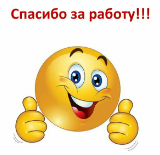